In [1]:
from ProjectFunctions import *

# Degeneracy 4 Analysis for N=8

## Hamming Distance 2

In [2]:
#generate the distance and find the hamming distance
length = 8
#generate field and interaction terms
Hfield = sg_field(length)
jij = generate_jij(length, 14, 9)
Hint, Hintdiag = sg_interaction(length, jij)
#construct hamiltonian and find groundstate
H = Hint + (0.01 * Hfield)
E, psi = H.groundstate()
#find hamming distance between classical ground states
hamming_distance(length, Hintdiag)
#find and print classical groundstates
minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
print(states)

The hamming distance is 2 for states 00100101 and 00110001
The hamming distance is 6 for states 00100101 and 11001110
The hamming distance is 6 for states 00110001 and 11011010
The hamming distance is 2 for states 11001110 and 11011010
['00100101', '00110001', '11001110', '11011010']


C:\Users\danny\anaconda3\Lib\site-packages\qutip\core\qobj.py:1626: UserWarning: Ground state may be degenerate.
  warnings.warn("Ground state may be degenerate.", UserWarning)


In [3]:
minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
#find probabilities for each groundstate over a range of h values to find an h value where they are in an equal superposition
probsoverh, probs1, probs2, probs3, probs4 = groundstate_prob(length, jij, np.linspace(0.0001,10,100))

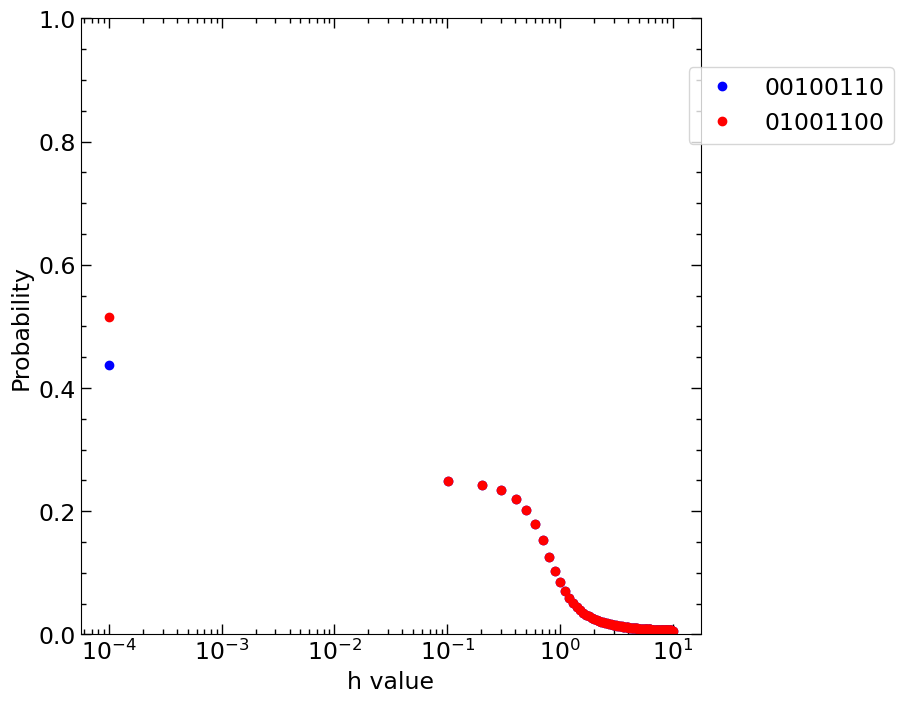

In [16]:
#create the plot
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel("h value")
ax.set_ylabel("Probability")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_xscale('log')
ax.set_ylim(0,1)

p1 = plt.plot(probsoverh.keys(), probs1, 'ob', label = states[0])
p2 = plt.plot(probsoverh.keys(), probs2, 'or', label = states[1])
plt.legend(loc='upper right', bbox_to_anchor=(1.33, 0.94))
plt.show()

In [5]:
#construct a vector that is an equal superposition of the classical groundstates to compare to the quantum groundstate
statevecs = simplified_groundstate(length, states)
simpleground = (1/np.sqrt(2))*(((1/np.sqrt(2)) * (statevecs[0] + statevecs[3])) + ((1/np.sqrt(2)) * (statevecs[1] + statevecs[2])))

In [6]:
#find the mutual info distance at this h value for the quantum groundstate
minfo1 = []
distancelist1 = []
for i in range(length):
    for j in range(i + 1, length):
        mutualinfo, distance= mutual_info(length, psi, [i], [j])
        distancelist1.append(distance)
        minfo1.append(mutualinfo)

In [7]:
#find the mutual info distance at this h value for the classical superposition state
distancelist2 = []
minfo2 = []
for i in range(length):
    for j in range(i + 1, length):
        mutualinfo, distance = mutual_info(length, simpleground, [i], [j])
        distancelist2.append(distance)
        minfo2.append(mutualinfo)

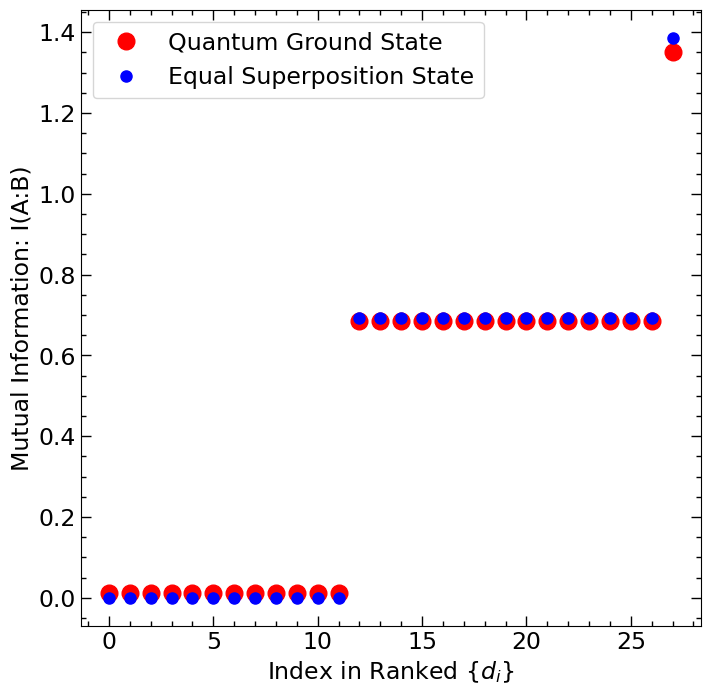

In [8]:
#Plot the mutual info list of quantum and classical groundstates
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel(r"Index in Ranked $\{d_i\}$")
ax.set_ylabel("Mutual Information: I(A:B)")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')


#here the distance values are sorted to better see the distinct levels of mutual information distance
p1 = plt.plot(range(28), sorted(minfo1), 'or', markersize = 12, label = "Quantum Ground State")
p2 = plt.plot(range(28), sorted(minfo2), 'ob', markersize = 8, label = "Equal Superposition State")
plt.legend()
plt.show()

## Hamming Distance 4

In [9]:
#generate the distance and find the hamming distance
length = 8
#generate field and interaction terms
Hfield = sg_field(length)
jij = generate_jij(length, 14, 5001)
Hint, Hintdiag = sg_interaction(length, jij)
#construct hamiltonian and find groundstate
H = Hint + (0.01 * Hfield)
E, psi = H.groundstate()
#find hamming distance between classical ground states
hamming_distance(length, Hintdiag)
#find and print classical groundstates
minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
print(states)

The hamming distance is 4 for states 00100110 and 01001100
The hamming distance is 4 for states 00100110 and 10110011
The hamming distance is 4 for states 01001100 and 11011001
The hamming distance is 4 for states 10110011 and 11011001
['00100110', '01001100', '10110011', '11011001']


In [10]:
minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
#find probabilities for each groundstate over a range of h values to find an h value where they are in an equal superposition
probsoverh, probs1, probs2, probs3, probs4 = groundstate_prob(length, jij, np.linspace(0.0001,10,100))

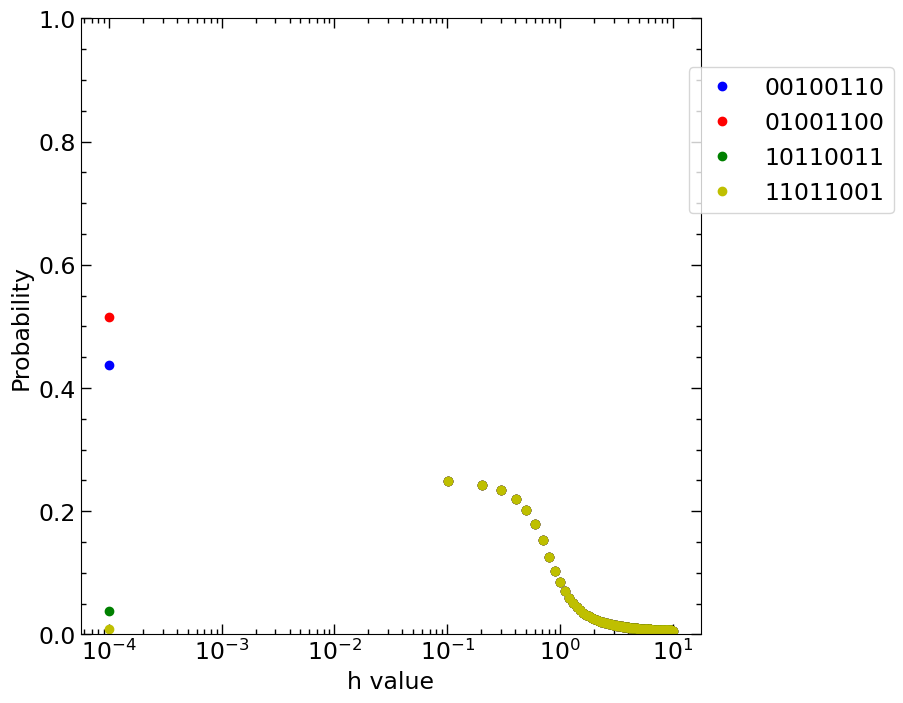

In [11]:
#create the plot
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel("h value")
ax.set_ylabel("Probability")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_xscale('log')
ax.set_ylim(0,1)

p1 = plt.plot(probsoverh.keys(), probs1, 'ob', label = states[0])
p2 = plt.plot(probsoverh.keys(), probs2, 'or', label = states[1])
p3 = plt.plot(probsoverh.keys(), probs3, 'og', label = states[2])
p4 = plt.plot(probsoverh.keys(), probs4, 'oy', label = states[3])
plt.legend(loc='upper right', bbox_to_anchor=(1.33, 0.94))
plt.show()

In [12]:
#construct a vector that is an equal superposition of the classical groundstates to compare to the quantum groundstate
statevecs = simplified_groundstate(length, states)
simpleground = (1/np.sqrt(2))*(((1/np.sqrt(2)) * (statevecs[0] + statevecs[3])) + ((1/np.sqrt(2)) * (statevecs[1] + statevecs[2])))

In [13]:
#find the mutual info distance at this h value for the quantum groundstate
minfo1 = []
distancelist1 = []
for i in range(length):
    for j in range(i + 1, length):
        mutualinfo, distance= mutual_info(length, psi, [i], [j])
        distancelist1.append(distance)
        minfo1.append(mutualinfo)

In [14]:
#find the mutual info distance at this h value for the classical superposition state
distancelist2 = []
minfo2 = []
for i in range(length):
    for j in range(i + 1, length):
        mutualinfo, distance = mutual_info(length, simpleground, [i], [j])
        distancelist2.append(distance)
        minfo2.append(mutualinfo)

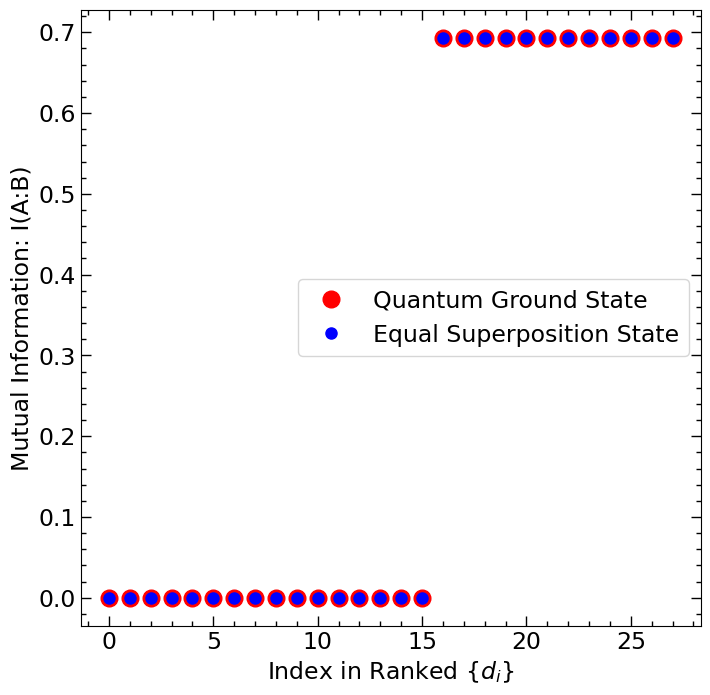

In [15]:
#Plot the mutual info list of quantum and classical groundstates
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel(r"Index in Ranked $\{d_i\}$")
ax.set_ylabel("Mutual Information: I(A:B)")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')


#here the distance values are sorted to better see the distinct levels of mutual information distance
p1 = plt.plot(range(28), sorted(minfo1), 'or', markersize = 12, label = "Quantum Ground State")
p2 = plt.plot(range(28), sorted(minfo2), 'ob', markersize = 8, label = "Equal Superposition State")
plt.legend()
plt.show()